In [61]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [62]:
ds = xr.open_dataset('data/wget_data/vpd_2018.nc')
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:                      (day: 365, lat: 585, lon: 1386, crs: 1)
Coordinates:
  * day                          (day) datetime64[ns] 3kB 2018-01-01 ... 2018...
  * lat                          (lat) float64 5kB 49.4 49.36 ... 25.11 25.07
  * lon                          (lon) float64 11kB -124.8 -124.7 ... -67.06
  * crs                          (crs) uint16 2B 3
Data variables:
    mean_vapor_pressure_deficit  (day, lat, lon) float64 2GB ...
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       26 April 2021
    note1:                      The projection information for this file is: ...
    note2:            

Let's restrict to the longitude and Latitude we are most interested in. According to the (American Library Association Open File Report 86-3-CA)[https://www.ala.org/magirt/publicationsab/ca], the longitude and latitude bounds for Butte county are **W 122 deg 05´--W 121 deg 04´/N 40 deg 10´--N 39 deg 17´**. The data set here stores these in decimal format instead, so we will convert to decimal format and get **Longitude:  -122.083333 -- -121.066667** and **Latitude: 40.166667 -- 39.283333**. We will use this as our bounding box for Butte County. 

In [63]:
lat_min = 35.283333
lat_max = 45.166667 
lon_min = -125.083333 
lon_max = -119.066667 

butte = ds.sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)
print(butte)
print(f"\nShape: {butte['mean_vapor_pressure_deficit'].shape}")

<xarray.Dataset> Size: 95MB
Dimensions:                      (day: 365, lat: 237, lon: 137, crs: 1)
Coordinates:
  * day                          (day) datetime64[ns] 3kB 2018-01-01 ... 2018...
  * lat                          (lat) float64 2kB 45.15 45.11 ... 35.36 35.32
  * lon                          (lon) float64 1kB -124.8 -124.7 ... -119.1
  * crs                          (crs) uint16 2B 3
Data variables:
    mean_vapor_pressure_deficit  (day, lat, lon) float64 95MB ...
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       26 April 2021
    note1:                      The projection information for this file is: ...
    note2:           

Next, we will restrict to the fire season months May 1 - November 30 annually from 2016-present.

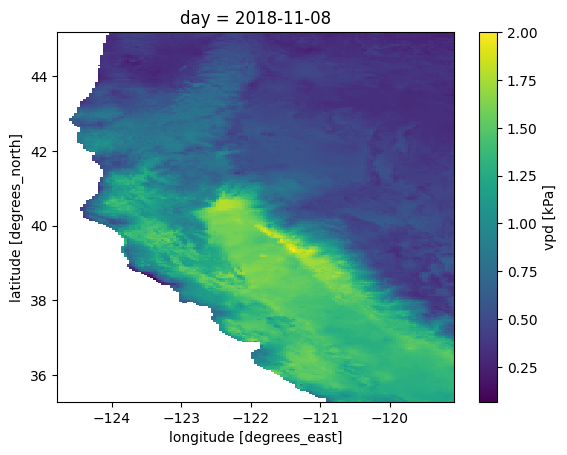

In [64]:
date_start = '2018-05-01'
date_end = '2018-11-30'
fire_season = butte.sel(
    day = slice(date_start,date_end)
    )

fire_season['mean_vapor_pressure_deficit'].sel(day = '2018-11-08').plot()

/var/folders/57/j7359fzj3n7g0sxmfg939lb40000gn/T/ipykernel_55662/655371306.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


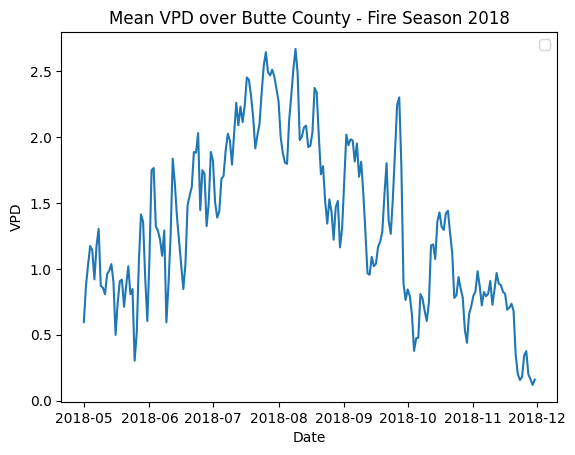

In [65]:
fire_season_mean = fire_season['mean_vapor_pressure_deficit'].mean(dim=['lat', 'lon'])

plt.plot(fire_season_mean.day, fire_season_mean)
plt.title('Mean VPD over Butte County - Fire Season 2018')
plt.ylabel('VPD')
plt.xlabel('Date')
plt.legend()
plt.show()

/var/folders/57/j7359fzj3n7g0sxmfg939lb40000gn/T/ipykernel_55662/458286378.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


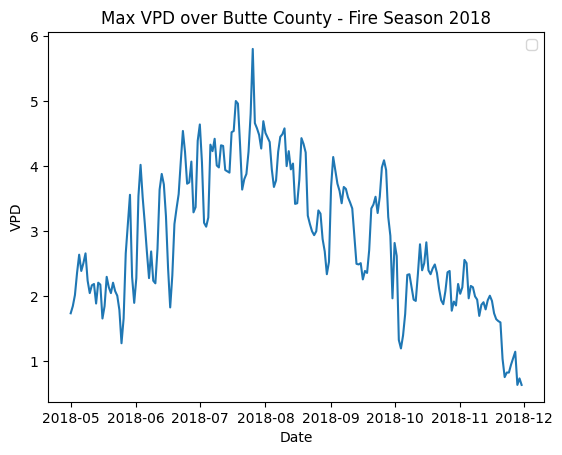

In [66]:
fire_season_max = fire_season['mean_vapor_pressure_deficit'].max(dim=['lat', 'lon'])

plt.plot(fire_season_mean.day, fire_season_max)
plt.title('Max VPD over Butte County - Fire Season 2018')
plt.ylabel('VPD')
plt.xlabel('Date')
plt.legend()
plt.show()